Magnitude shape: (1025, 63)
Power shape: (1025, 63)


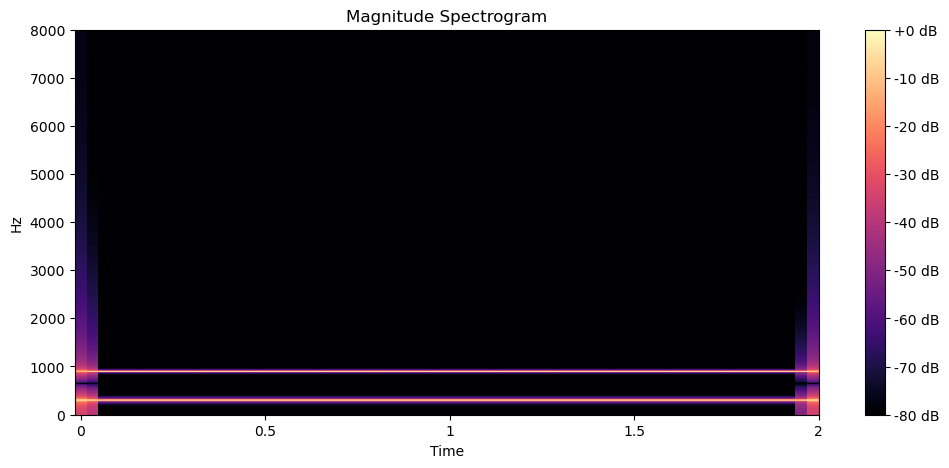

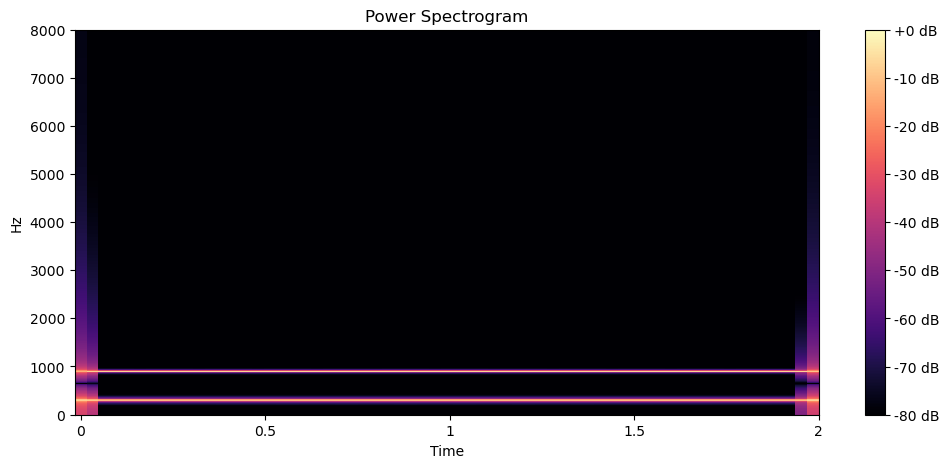

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

sample_rate = 16000
duration = 2.0

N = int(sample_rate * duration)
time = np.arange(N) / sample_rate

signal = (
    np.sin(2 * np.pi * 300 * time)
    +
    0.4 * np.sin(2 * np.pi * 900 * time)
)

stft_result = librosa.stft(
    signal,
    n_fft=2048,
    hop_length=512,
    win_length=2048
)

# Magnitude
magnitude = np.abs(stft_result)

# Power
power = magnitude ** 2

print("Magnitude shape:", magnitude.shape)
print("Power shape:", power.shape)

magnitude_db = librosa.amplitude_to_db(
    magnitude,
    ref=np.max
)

power_db = librosa.power_to_db(
    power,
    ref=np.max
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    magnitude_db,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Magnitude Spectrogram")
plt.show()

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    power_db,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram")
plt.show()

In [ ]:
#Also, if you see some slight vertical energy near the very beginning/end, that's from the signal boundaries/windowing rather than a new frequency component.